NameError: name 'max_ind' is not defined

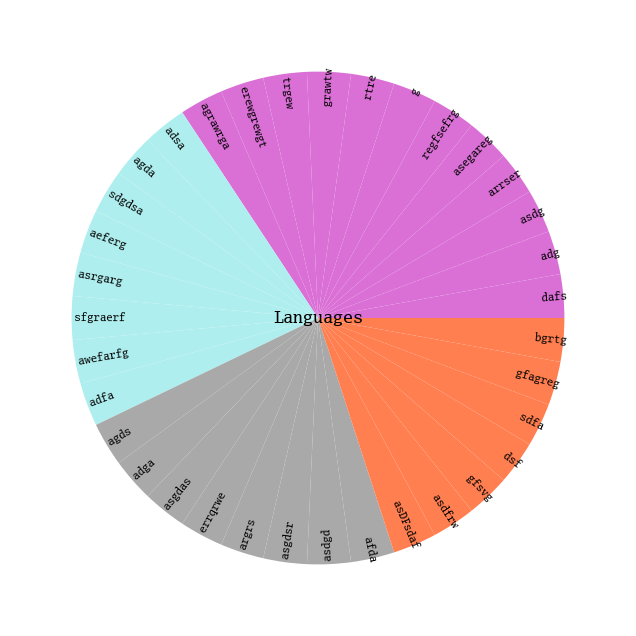

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
from matplotlib import font_manager as fm
import matplotlib.patches as patches
import random

def giveFig(wedge1, fileName, whitey=False, label12=False, lw=1, dpi1=300,l=7.2,b=7.2):
    if whitey==False:
        lw = 0

    def get_column_colors(categories, ask_user=True):
        available_colors = list(mcolors.CSS4_COLORS.keys())
        column_colors = []
        for i, category in enumerate(categories):
            if ask_user:
                print(f"\nChoose a color for column '{category}':")
                print("\nAvailable colors:", available_colors)
                chosen_color = input("\nEnter color name or hex value: ").lower()

                while chosen_color not in mcolors.CSS4_COLORS and chosen_color not in available_colors:
                    print("Invalid color! Please choose from the available colors.")
                    chosen_color = input("Enter color name or hex value: ").lower()

                if chosen_color in available_colors:
                    available_colors.remove(chosen_color)
            else:
                chosen_color = random.choice(available_colors)
                available_colors.remove(chosen_color)

            column_colors.append(chosen_color)
        return column_colors
    
    tamil_font_path = r"Noto_Sans_Tamil/NotoSansTamil-VariableFont_wdth,wght.ttf"
    tamil_prop = fm.FontProperties(fname=tamil_font_path)

    english_font_path = r"Luxi-Mono/luximr.ttf"
    english_prop = fm.FontProperties(fname=english_font_path)
    
    english_prop.set_size(7.7)
    tamil_prop.set_size(8.5)

    df = pd.read_csv(r"C:\Users\pavan\StudioProjects\UK_Client\sample.csv", encoding='utf-8')

    categories = df.columns
    
    column_colors = get_column_colors(categories, ask_user=False)

    outer_data = []
    outer_labels = []
    colors = []
    column_counts = []
    flagi = []
    counter = 0

    dfFor = pd.read_csv(r"C:\Users\pavan\StudioProjects\UK_Client\sample.csv")
    mapping = {column: dfFor[column].count() for column in dfFor.columns}

    
    for i, category in enumerate(categories):
        category_values = df[category].dropna().unique()
        leng1 = len(category_values)        
        unique_colors = dict(zip(category_values, [column_colors[i % len(column_colors)]] * len(category_values)))
        
        for value in category_values:
            count = len(df[df[category] == value])
            
            
            label = str(value)
            color = unique_colors[value]
            threshold = 31
            if (counter == 0):
                    counter = 1
            else:
                counter = 0
            if len(label) > threshold:
                mapping[categories[i]] += 1
                leng1+=1
                words = label.split()
                first_line = ""
                second_line = ""
                for word in words:
                    if len(first_line) + len(word) + 1 <= threshold:
                        first_line += word + " "
                    else:
                        second_line += word + " "
                outer_data.append(count)
                outer_data.append(count)
                flagi.append(counter)
                flagi.append(counter)
                first_line = first_line.rstrip()
                second_line = second_line.rstrip()
                outer_labels.append(first_line)
                colors.append(color)
                
                if second_line: 
                    outer_labels.append(second_line)
                    colors.append(color)
            else:
                label = label.rstrip()
                flagi.append(counter)
                outer_data.append(count)
                outer_labels.append(label)
                colors.append(color)
        column_counts.append(leng1)

    pseudo_ind = []
    ing = 0
    for i in mapping.values():
        pseudo_ind.append(ing + (i//2))
        ing += i
    

    fig, ax = plt.subplots(figsize=(l, b), dpi=dpi1)

    size = 0.33
    wedgeprops_outer = dict(width=1.0, edgecolor='black')

    newl = []
    for i, element in enumerate(outer_labels):
        length = len(outer_labels)
        n = length // 4
        start = n+1
        end = length - n - 1
        if start <= i <= end:
            newl.append([element, "left"])
        else:
            newl.append([element, "right"])

    
    for i in range(0,len(flagi)-1):
        if (flagi[i] == flagi[i+1] and newl[i][1] == newl[i+1][1] == "right"):
            outer_labels[i], outer_labels[i+1] = outer_labels[i+1], outer_labels[i]


    def is_tamil(text):
        tamil_unicode_range = range(0x0B80, 0x0BFF)
        return any(ord(char) in tamil_unicode_range for char in text)
    

    def autopct_format(pct):
        threshold = 31
        label = outer_labels.pop(0)
        pos = ""
        for i, ele in enumerate(newl):
            if ele[0] == label:
                pos = ele[1]
        if pos == "right":
            if is_tamil(label):
                if len(label) > threshold:
                    label = "  " + label
                    words = label.split()
                    first_line = ""
                    second_line = ""
                    for word in words:
                        if len(first_line) + len(word) + 1 <= threshold:
                            first_line += word + " "
                        else:
                            second_line += word + " "
                    first_line = first_line.rstrip()
                    second_line = second_line.rstrip()
                    spaces_to_add_first = threshold - len(first_line)
                    spaces_to_add_second = threshold - len(second_line)
                    return f"{' ' * spaces_to_add_first*2}{'       '}{first_line}\n{' ' * spaces_to_add_second*2}{'           '}{second_line}{''}"
                spaces = threshold - len(label)-3
                return f" {' ' * spaces*2}{''}{label}"
            else:
                threshold = 31 
                if len(label) > threshold:
                    label = "  " + label
                    words = label.split()
                    first_line = ""
                    second_line = ""
                    for word in words:
                        if len(first_line) + len(word) + 1 <= threshold:
                            first_line += word + " "
                        else:
                            second_line += word + " "
                    first_line = first_line.rstrip()
                    second_line = second_line.rstrip()
                    spaces_to_add_first = threshold - len(first_line)
                    spaces_to_add_second = threshold - len(second_line)
                    return f"{' ' * spaces_to_add_first}{first_line}\n{' ' * spaces_to_add_second}{second_line}{''}"
                spaces = threshold - len(label)
                return f" {' ' * spaces}{label}"

        else:
            if is_tamil(label):
                if len(label) > threshold:
                    label = "  " + label
                    words = label.split()
                    first_line = ""
                    second_line = ""
                    for word in words:
                        if len(first_line) + len(word) + 1 <= threshold:
                            first_line += word + " "
                        else:
                            second_line += word + " "
                    first_line = first_line.rstrip()
                    second_line = second_line.rstrip()
                    spaces_to_add_first = threshold - len(first_line)
                    spaces_to_add_second = threshold - len(second_line)
                    return f"{first_line}{' ' * spaces_to_add_first}\n{second_line}{' ' * spaces_to_add_second }"
                spaces = threshold - len(label)
                return f" {label}{' ' * spaces }"
            else:
                threshold = 31 
                if len(label) > threshold:
                    label = "  " + label
                    words = label.split()
                    first_line = ""
                    second_line = ""
                    for word in words:
                        if len(first_line) + len(word) + 1 <= threshold:
                            first_line += word + " "
                        else:
                            second_line += word + " "
                    first_line = first_line.rstrip()
                    second_line = second_line.rstrip()
                    spaces_to_add_first = threshold - len(first_line)
                    spaces_to_add_second = threshold - len(second_line)
                    return f"{first_line}{' ' * spaces_to_add_first}\n{second_line}{' ' * spaces_to_add_second }"
                spaces = threshold - len(label)
                return f" {label}{' ' * spaces }"

        return label

    if whitey:
        clen = len(colors)
        for i in range(0, clen):
            colors[i] = 'white'
    outer_wedges, outer_texts, outer_autotexts = ax.pie(outer_data, labels=None, startangle=-0, colors=colors,
                                                        autopct=autopct_format, textprops={ 'fontproperties': english_prop}, wedgeprops=wedgeprops_outer if wedge1 else {})
    
    
    pie_colors = column_colors

    fileName = fileName
    plt.text(0, 0, fileName, fontsize=12, color='black', ha='center', va='center', fontproperties=english_prop)

    angles = np.linspace(0, 2 * np.pi, len(outer_data), endpoint=False).tolist()
    angles1 = []
    leng = len(outer_data)
    
    jump = 360.0 / len(outer_data)
    add = 179.95*np.power(leng,-1.01)
    
    for i in np.arange(0.0, 360.0, jump):
        if 90 < i < 271:
            angles1.append(i + 180 + add)
        else:
            angles1.append(i + add)
    
    for index, (angle, auto_text) in enumerate(zip(angles1, outer_autotexts)):
        auto_text.set_rotation(angles1[index])
        if is_tamil(auto_text.get_text()):
            auto_text.set_fontproperties(tamil_prop)
        else:
            auto_text.set_fontproperties(english_prop)

    num_columns = len(df.columns)

    categories = list(categories)

    def wrap_text(text, max_length=16, ind=-1):
        global max_len 
        global max_ind
        max_len = -1
        max_ind = ind
        words = text.split()
        result = []
        current_line = ""
    
        for word in words:
            if len(current_line) + len(word) <= max_length:
                current_line += word + " "
            else:
                result.append(current_line.strip())
                current_line = word + " "
    
        if current_line:
            result.append(current_line.strip())
        for val in result:
            max_len = max(max_len,len(val))

        return "\n".join(result)

    for i, category in enumerate(categories):
        if len(category) > 8:
            categories[i] = wrap_text(category,max_length=16,ind=i)

    for i,val in enumerate(categories):
        if i != max_ind:
            cur_len = len(val)
            req_len = max_len - cur_len
            if req_len%2==0:
                categories[i] = " "*(req_len//2) + categories[i] + " "*(req_len//2)
            else:
                categories[i] = " "*(req_len//2) + categories[i] + " "*((req_len//2)+1)

    english_prop2 = fm.FontProperties(fname=english_font_path, size=9)
    
    zind = 0
    for i, p in enumerate(outer_wedges):
        if (i in pseudo_ind):
            bbox_props = dict(boxstyle="square,pad=1.8", fc= 'white' if whitey else pie_colors[zind], ec= 'black' if whitey else pie_colors[zind], lw=lw)
            kw = dict(arrowprops=dict(arrowstyle="<-", color= 'black' if whitey else pie_colors[zind], lw = 2.5),
                      
                        bbox=bbox_props, zorder=0, va="center")
            ang = (p.theta2 - p.theta1)/2. + p.theta1
            y = np.sin(np.deg2rad(ang))
            x = np.cos(np.deg2rad(ang))
            horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
            connectionstyle = f"angle,angleA=0,angleB={ang}"
            # connectionstyle = f"arc,angleA=0,angleB={ang},armA=10,armB=40,rad=0"
            kw["arrowprops"].update({"connectionstyle": connectionstyle})
            ax.annotate( categories[zind], xy=(x, y), xytext=(1.35*np.sign(x), 1.4*y),
                        
                        horizontalalignment=horizontalalignment, **kw, fontproperties=english_prop2)
            zind += 1

    plt.axis('equal')
    


    

    circle_radius = 0.25
    cumulative_counts = np.cumsum(column_counts)
    for count in cumulative_counts[:-1]: 
        angle = np.degrees(angles[count])
        x_inner = circle_radius * np.cos(np.deg2rad(angle))
        y_inner = circle_radius * np.sin(np.deg2rad(angle))
        x_outer = np.cos(np.deg2rad(angle))
        y_outer = np.sin(np.deg2rad(angle))
        line, = ax.plot([x_outer, x_inner], [y_outer, y_inner], color='black', linewidth=lw)
    
    last_column_count = cumulative_counts[-1]
    angle_index = last_column_count % len(angles)  
    angle = np.degrees(angles[angle_index])
    x_inner = circle_radius * np.cos(np.deg2rad(angle))
    y_inner = circle_radius * np.sin(np.deg2rad(angle))
    x_outer = np.cos(np.deg2rad(angle))
    y_outer = np.sin(np.deg2rad(angle))
    line, = ax.plot([x_outer, x_inner], [y_outer, y_inner], color='black', linewidth=lw)

    circle = patches.Circle((0, 0), radius=circle_radius, edgecolor='black' if whitey else 'white', facecolor='white', linewidth=lw) 
    ax.add_artist(circle)
    
    circle_radius1 = 1 
    circle1 = patches.Circle((0, 0), radius=circle_radius1, edgecolor='black' if whitey else 'white', facecolor='none', linewidth=lw) 
    ax.add_artist(circle1)
    # plt.savefig('output.png', dpi=dpi1, bbox_inches='tight')
    # ax.legend(handles=[patches.Patch(color=color, label=category) for color, category in zip(column_colors, categories)], loc="lower right", bbox_to_anchor=(1, 0))
    ax.grid(True, linestyle='--', color='gray', alpha=0.7)
    plt.show()
    

random.seed(38)
giveFig(False, "Languages", False,True,lw=1,dpi1=100,l=24,b=8)


In [4]:
import matplotlib.colors as mcolors

In [5]:
available_colors = list(mcolors.CSS4_COLORS.keys())

In [6]:
print(available_colors)

['aliceblue', 'antiquewhite', 'aqua', 'aquamarine', 'azure', 'beige', 'bisque', 'black', 'blanchedalmond', 'blue', 'blueviolet', 'brown', 'burlywood', 'cadetblue', 'chartreuse', 'chocolate', 'coral', 'cornflowerblue', 'cornsilk', 'crimson', 'cyan', 'darkblue', 'darkcyan', 'darkgoldenrod', 'darkgray', 'darkgreen', 'darkgrey', 'darkkhaki', 'darkmagenta', 'darkolivegreen', 'darkorange', 'darkorchid', 'darkred', 'darksalmon', 'darkseagreen', 'darkslateblue', 'darkslategray', 'darkslategrey', 'darkturquoise', 'darkviolet', 'deeppink', 'deepskyblue', 'dimgray', 'dimgrey', 'dodgerblue', 'firebrick', 'floralwhite', 'forestgreen', 'fuchsia', 'gainsboro', 'ghostwhite', 'gold', 'goldenrod', 'gray', 'green', 'greenyellow', 'grey', 'honeydew', 'hotpink', 'indianred', 'indigo', 'ivory', 'khaki', 'lavender', 'lavenderblush', 'lawngreen', 'lemonchiffon', 'lightblue', 'lightcoral', 'lightcyan', 'lightgoldenrodyellow', 'lightgray', 'lightgreen', 'lightgrey', 'lightpink', 'lightsalmon', 'lightseagreen', 

In [7]:
import os
import requests
from PIL import Image, ImageDraw

def create_color_image(color_name, size=(100, 100)):
    image = Image.new('RGB', size, color=color_name)
    draw = ImageDraw.Draw(image)
    return image

def save_color_images(colors, folder_name='colors'):
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for color in colors:
        img = create_color_image(color)
        img.save(f"{folder_name}/{color}.png")
        print(f"Saved {color}.png")

# List of color names
colors = ['aliceblue', 'antiquewhite', 'aqua', 'aquamarine', 'azure', 'beige', 'bisque', 'black', 'blanchedalmond', 'blue', 'blueviolet', 'brown', 'burlywood', 'cadetblue', 'chartreuse', 'chocolate', 'coral', 'cornflowerblue', 'cornsilk', 'crimson', 'cyan', 'darkblue', 'darkcyan', 'darkgoldenrod', 'darkgray', 'darkgreen', 'darkgrey', 'darkkhaki', 'darkmagenta', 'darkolivegreen', 'darkorange', 'darkorchid', 'darkred', 'darksalmon', 'darkseagreen', 'darkslateblue', 'darkslategray', 'darkslategrey', 'darkturquoise', 'darkviolet', 'deeppink', 'deepskyblue', 'dimgray', 'dimgrey', 'dodgerblue', 'firebrick', 'floralwhite', 'forestgreen', 'fuchsia', 'gainsboro', 'ghostwhite', 'gold', 'goldenrod', 'gray', 'green', 'greenyellow', 'grey', 'honeydew', 'hotpink', 'indianred', 'indigo', 'ivory', 'khaki', 'lavender', 'lavenderblush', 'lawngreen', 'lemonchiffon', 'lightblue', 'lightcoral', 'lightcyan', 'lightgoldenrodyellow', 'lightgray', 'lightgreen', 'lightgrey', 'lightpink', 'lightsalmon', 'lightseagreen', 'lightskyblue', 'lightslategray', 'lightslategrey', 'lightsteelblue', 'lightyellow', 'lime', 'limegreen', 'linen', 'magenta', 'maroon', 'mediumaquamarine', 'mediumblue', 'mediumorchid', 'mediumpurple', 'mediumseagreen', 'mediumslateblue', 'mediumspringgreen', 'mediumturquoise', 'mediumvioletred', 'midnightblue', 'mintcream', 'mistyrose', 'moccasin', 'navajowhite', 'navy', 'oldlace', 'olive', 'olivedrab', 'orange', 'orangered', 'orchid', 'palegoldenrod', 'palegreen', 'paleturquoise', 'palevioletred', 'papayawhip', 'peachpuff', 'peru', 'pink', 'plum', 'powderblue', 'purple', 'rebeccapurple', 'red', 'rosybrown', 'royalblue', 'saddlebrown', 'salmon', 'sandybrown', 'seagreen', 'seashell', 'sienna', 'silver', 'skyblue', 'slateblue', 'slategray', 'slategrey', 'snow', 'springgreen', 'steelblue', 'tan', 'teal', 'thistle', 'tomato', 'turquoise', 'violet', 'wheat', 'white', 'whitesmoke', 'yellow', 'yellowgreen']

# Call the function to save all color images
save_color_images(colors)

Saved aliceblue.png
Saved antiquewhite.png
Saved aqua.png
Saved aquamarine.png
Saved azure.png
Saved beige.png
Saved bisque.png
Saved black.png
Saved blanchedalmond.png
Saved blue.png
Saved blueviolet.png
Saved brown.png
Saved burlywood.png
Saved cadetblue.png
Saved chartreuse.png
Saved chocolate.png
Saved coral.png
Saved cornflowerblue.png
Saved cornsilk.png
Saved crimson.png
Saved cyan.png
Saved darkblue.png
Saved darkcyan.png
Saved darkgoldenrod.png
Saved darkgray.png
Saved darkgreen.png
Saved darkgrey.png
Saved darkkhaki.png
Saved darkmagenta.png
Saved darkolivegreen.png
Saved darkorange.png
Saved darkorchid.png
Saved darkred.png
Saved darksalmon.png
Saved darkseagreen.png
Saved darkslateblue.png
Saved darkslategray.png
Saved darkslategrey.png
Saved darkturquoise.png
Saved darkviolet.png
Saved deeppink.png
Saved deepskyblue.png
Saved dimgray.png
Saved dimgrey.png
Saved dodgerblue.png
Saved firebrick.png
Saved floralwhite.png
Saved forestgreen.png
Saved fuchsia.png
Saved gainsboro.p